<a href="https://colab.research.google.com/github/maraymtaher/projet_IA/blob/main/notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

#  Le dépôt la coopérative (point de départ et d'arrivée)
depot = {
    "id": 0,
    "nom": "Coopérative centrale",
    "lat": 12.100,
    "lon": 15.050,
    "ouverture": 5.5,    # 05h30
    "fermeture": 12.0,   # 12h00 — limite de retour
    "volume": 0,
    "duree_collecte": 0
}

#jeu de données de 15 éleveurs
eleveurs = [
    {"id":1,  "nom":"Tahir",   "lat":12.105,"lon":15.044,"ouverture":6.0,"fermeture":8.0, "volume":40,"duree_collecte":0.25},
    {"id":2,  "nom":"Fatima",   "lat":12.089,"lon":15.071,"ouverture":7.0,"fermeture":9.0, "volume":25,"duree_collecte":0.25},
    {"id":3,  "nom":"Wael",   "lat":12.132,"lon":15.028,"ouverture":6.5,"fermeture":8.5, "volume":60,"duree_collecte":0.33},
    {"id":4,  "nom":"Amina",    "lat":12.118,"lon":15.093,"ouverture":8.0,"fermeture":10.0,"volume":35,"duree_collecte":0.25},
    {"id":5,  "nom":"Youssef",  "lat":12.077,"lon":15.055,"ouverture":7.5,"fermeture":9.5, "volume":50,"duree_collecte":0.33},
    {"id":6,  "nom":"Marayim",   "lat":12.143,"lon":15.067,"ouverture":6.0,"fermeture":8.0, "volume":45,"duree_collecte":0.25},
    {"id":7,  "nom":"Saleh",   "lat":12.091,"lon":15.038,"ouverture":7.0,"fermeture":9.0, "volume":30,"duree_collecte":0.25},
    {"id":8,  "nom":"Nafissa",     "lat":12.125,"lon":15.082,"ouverture":6.5,"fermeture":8.5, "volume":55,"duree_collecte":0.33},
    {"id":9,  "nom":"Mahamat",  "lat":12.112,"lon":15.031,"ouverture":8.0,"fermeture":10.0,"volume":20,"duree_collecte":0.17},
    {"id":10, "nom":"Zahra",     "lat":12.083,"lon":15.063,"ouverture":7.0,"fermeture":9.0, "volume":65,"duree_collecte":0.33},
    {"id":11, "nom":"Younouss",   "lat":12.137,"lon":15.048,"ouverture":6.0,"fermeture":8.5, "volume":38,"duree_collecte":0.25},
    {"id":12, "nom":"Khadija",  "lat":12.096,"lon":15.085,"ouverture":7.5,"fermeture":9.5, "volume":42,"duree_collecte":0.25},
    {"id":13, "nom":"Mustafa",    "lat":12.121,"lon":15.019,"ouverture":6.5,"fermeture":8.5, "volume":58,"duree_collecte":0.33},
    {"id":14, "nom":"Halima",   "lat":12.074,"lon":15.047,"ouverture":8.0,"fermeture":10.0,"volume":33,"duree_collecte":0.25},
    {"id":15, "nom":"Mouss-ab",   "lat":12.149,"lon":15.076,"ouverture":7.0,"fermeture":9.5, "volume":48,"duree_collecte":0.33},
]

# Paramètres globaux
CAPACITE_CAMION = 500   # litres
VITESSE_MOYENNE = 40    # km/h

#Vérification
print("=" * 50)
print(" Dépôt :", depot["nom"])
print(f" {len(eleveurs)} éleveurs chargés\n")
print(f"{'ID':<4} {'Nom':<10} {'Ouverture':>10} {'Fermeture':>10} {'Volume':>8}")
print("-" * 50)
for e in eleveurs:
    print(f"{e['id']:<4} {e['nom']:<10} {e['ouverture']:>9}h {e['fermeture']:>9}h {e['volume']:>6}L")

total = sum(e["volume"] for e in eleveurs)
print("=" * 50)
print(f" Volume total : {total}L  |  Capacité camion : {CAPACITE_CAMION}L")
print(f"{' Camion suffisant' if total <= CAPACITE_CAMION else 'Dépasse la capacité — il faudra 2 tournées'}")
print("=" * 50)

 Dépôt : Coopérative centrale
 15 éleveurs chargés

ID   Nom         Ouverture  Fermeture   Volume
--------------------------------------------------
1    Tahir            6.0h       8.0h     40L
2    Fatima           7.0h       9.0h     25L
3    Wael             6.5h       8.5h     60L
4    Amina            8.0h      10.0h     35L
5    Youssef          7.5h       9.5h     50L
6    Marayim          6.0h       8.0h     45L
7    Saleh            7.0h       9.0h     30L
8    Nafissa          6.5h       8.5h     55L
9    Mahamat          8.0h      10.0h     20L
10   Zahra            7.0h       9.0h     65L
11   Younouss         6.0h       8.5h     38L
12   Khadija          7.5h       9.5h     42L
13   Mustafa          6.5h       8.5h     58L
14   Halima           8.0h      10.0h     33L
15   Mouss-ab         7.0h       9.5h     48L
 Volume total : 644L  |  Capacité camion : 500L
Dépasse la capacité — il faudra 2 tournées


In [ ]:
# Formule Haversine + Matrice de distances

import math

def haversine(point1, point2):
    """
    Calcule la distance en km entre deux points GPS.
    Chaque point est un dictionnaire avec "lat" et "lon".
    """
    R = 6371  # rayon de la Terre en km

    # Étape 1 : convertir les coordonnées de degrés en radians
    lat1 = math.radians(point1["lat"])
    lat2 = math.radians(point2["lat"])
    lon1 = math.radians(point1["lon"])
    lon2 = math.radians(point2["lon"])

    # Étape 2 : calculer les différences
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    # Étape 3 : la formule haversine proprement dite
    a = math.sin(dlat/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon/2)**2
    c = 2 * math.asin(math.sqrt(a))

    # Étape 4 : multiplier par le rayon de la Terre
    distance = R * c

    return round(distance, 2)  # arrondi à 2 décimales


# Test rapide avant de continuer
print(" TEST DE LA FONCTION HAVERSINE")
print("-" * 40)
d = haversine(eleveurs[0], eleveurs[1])  # Tahir → Fatima
print(f"Distance Tahir → Fatima : {d} km")

d2 = haversine(depot, eleveurs[0])       # Dépôt → Tahir
print(f"Distance Dépôt → Tahir  : {d2} km")


# Construction de la matrice de distances
# On regroupe tous les points : dépôt + 15 éleveurs
tous_les_points = [depot] + eleveurs   # liste de 16 points (index 0 à 15)

n = len(tous_les_points)  # = 16

# Créer un tableau vide 16×16 rempli de zéros
matrice = [[0.0] * n for _ in range(n)]

# Remplir le tableau : distance entre chaque paire de points
for i in range(n):
    for j in range(n):
        if i != j:  # la distance d'un point à lui-même = 0
            matrice[i][j] = haversine(tous_les_points[i], tous_les_points[j])

# Affichage de la matrice
print("\n MATRICE DE DISTANCES (km)")
print("-" * 55)

# Ligne d'en-tête avec les noms
noms = [p["nom"][:6] for p in tous_les_points]  # 6 premiers caractères
print(f"{'':8}", end="")
for nom in noms:
    print(f"{nom:>7}", end="")
print()

# Lignes de la matrice
for i in range(n):
    print(f"{noms[i]:8}", end="")
    for j in range(n):
        print(f"{matrice[i][j]:>7.1f}", end="")
    print()

print(f"\n Matrice {n}×{n} construite — {n*n} distances calculées")

 TEST DE LA FONCTION HAVERSINE
----------------------------------------
Distance Tahir → Fatima : 3.43 km
Distance Dépôt → Tahir  : 0.86 km

 MATRICE DE DISTANCES (km)
-------------------------------------------------------
         Coopér  Tahir Fatima   Wael  Amina Yousse Marayi  Saleh Nafiss Mahama  Zahra Younou Khadij Mustaf Halima Mouss-
Coopér      0.0    0.9    2.6    4.3    5.1    2.6    5.1    1.6    4.5    2.5    2.4    4.1    3.8    4.1    2.9    6.1
Tahir       0.9    0.0    3.4    3.5    5.5    3.3    4.9    1.7    4.7    1.6    3.2    3.6    4.6    3.2    3.5    6.0
Fatima      2.6    3.4    0.0    6.7    4.0    2.2    6.0    3.6    4.2    5.0    1.1    5.9    1.7    6.7    3.1    6.7
Wael        4.3    3.5    6.7    0.0    7.2    6.8    4.4    4.7    5.9    2.2    6.7    2.2    7.4    1.6    6.8    5.5
Amina       5.1    5.5    4.0    7.2    0.0    6.2    4.0    6.7    1.4    6.8    5.1    5.3    2.6    8.1    7.0    3.9
Yousse      2.6    3.3    2.2    6.8    6.2    0.0

In [ ]:
# — Visualisation sur carte interactive (Folium)
!pip install folium -q   # installation du bibliothèque folium pour la création des cartes

import folium

# Créer la carte centrée sur le dépôt
carte = folium.Map(
    location=[depot["lat"], depot["lon"]],
    zoom_start=13
)

#  Ajouter le dépôt en rose
folium.Marker(
    location=[depot["lat"], depot["lon"]],
    popup=f"{depot['nom']}\nDépart : {depot['ouverture']}h",
    tooltip=depot["nom"],
    icon=folium.Icon(color=" pink", icon="home")
).add_to(carte)

# Ajouter les 15 éleveurs en vert
for e in eleveurs:
    folium.Marker(
        location=[e["lat"], e["lon"]],
        popup=f" {e['nom']}\n {e['ouverture']}h – {e['fermeture']}h\n {e['volume']} L",
        tooltip=f"{e['nom']} ({e['volume']}L)",
        icon=folium.Icon(color="green", icon="user")
    ).add_to(carte)

# Afficher la carte dans le notebook
carte

/tmp/ipykernel_37349/426719885.py:17: UserWarning: color argument of Icon should be one of: {'darkblue', 'green', 'lightblue', 'darkpurple', 'cadetblue', 'orange', 'darkgreen', 'red', 'black', 'pink', 'white', 'lightgreen', 'blue', 'lightgray', 'purple', 'lightred', 'beige', 'darkred', 'gray'}.
  icon=folium.Icon(color=" pink", icon="home")


 Aperçu des 5 premiers jours d'historique :
      Tahir  Fatima  Wael  Amina  Youssef  Marayim  Saleh  Nafissa  Mahamat  \
Jour                                                                          
0      43.0    25.4  65.6   42.6     53.9     44.6   33.8     41.0     20.9   
1      40.1    29.2  53.6   28.2     62.6     52.4   25.6     68.8     15.3   
2      45.6    23.5  52.9   42.6     51.3     40.3   33.7     56.0     16.9   
3      51.6    25.4  68.0   37.3     56.1     51.2   38.4     54.9     23.6   
4      41.8    25.6  62.6   32.6     59.1     45.0   21.3     50.9     22.2   

      Zahra  Younouss  Khadija  Mustafa  Halima  Mouss-ab  
Jour                                                       
0      63.2      40.1     43.3     55.0    36.8      52.0  
1      62.1      36.6     30.1     56.2    35.1      49.6  
2      81.9      39.8     42.3     57.7    35.0      53.9  
3      70.9      47.7     40.3     79.6    34.8      44.3  
4      80.1      42.1     39.0     65.8   

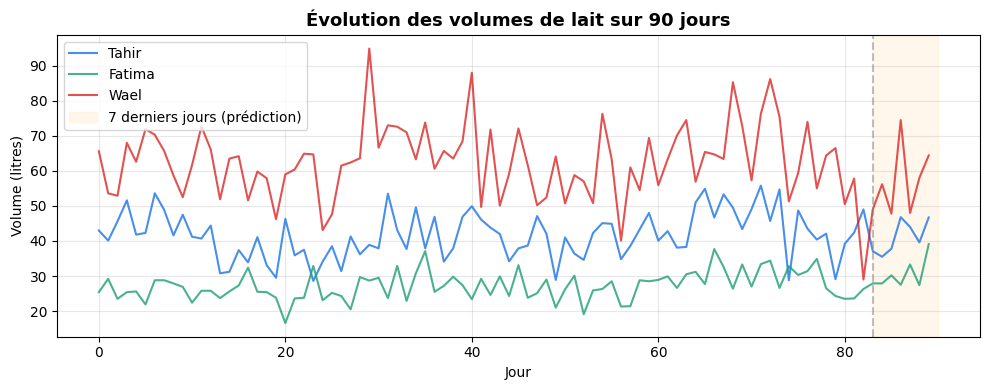

In [ ]:
#  Volumes prévisionnels avec historique et  prédiction
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # pour que les résultats soient reproductibles

#  Générer 90 jours d'historique pour chaque éleveur
historique = {}

for e in eleveurs:
    volumes_base = e["volume"]  # volume de référence déclaré

    # Simulation réaliste :
    # . tendance légèrement croissante (+0.05L par jour)
    # . variation saisonnière (sinus sur 30 jours)
    # . bruit aléatoire (±15% du volume de base)
    jours = np.arange(90)
    tendance    = jours * 0.05
    saisonniere = volumes_base * 0.1 * np.sin(2 * np.pi * jours / 30)
    bruit       = np.random.normal(0, volumes_base * 0.15, 90)

    volumes = volumes_base + tendance + saisonniere + bruit
    volumes = np.maximum(volumes, 5)  # minimum 5L (jamais négatif)
    volumes = np.round(volumes, 1)

    historique[e["nom"]] = volumes

# Convertir en DataFrame pandas (tableau structuré)
df = pd.DataFrame(historique)
df.index.name = "Jour"
print(" Aperçu des 5 premiers jours d'historique :")
print(df.head())

# --- Prédiction : moyenne mobile des 7 derniers jours ---
print("\n LES PRÉVISIONS POUR DEMAIN (moyenne des 7 derniers jours)")
print("-" * 50)

previsions = {}
for e in eleveurs:
    nom = e["nom"]
    derniers_7 = historique[nom][-7:]        # 7 derniers jours
    prediction  = round(float(np.mean(derniers_7)), 1)  # moyenne
    previsions[nom] = prediction
    print(f"  {nom:<12} : {prediction:>6.1f} L  (base déclarée : {e['volume']}L)")

# Mettre à jour les volumes dans la liste eleveurs
for e in eleveurs:
    e["volume_prevu"] = previsions[e["nom"]]

total_prevu = sum(previsions.values())
print(f"\n Volume total prévu demain : {total_prevu:.1f}L")
print(f"{' 1 tournée suffisante' if total_prevu <= CAPACITE_CAMION else ' 2 tournées nécessaires'}")

#  Graphique d'évolution du volume sur 90 jours (3 éleveurs)
fig, ax = plt.subplots(figsize=(10, 4))

couleurs = ["#1A73E8", "#1D9E75", "#DC2626"]
for i, nom in enumerate(["Tahir", "Fatima", "Wael"]):
    ax.plot(historique[nom], color=couleurs[i], label=nom, linewidth=1.5, alpha=0.8)

ax.axvline(x=83, color="gray", linestyle="--", alpha=0.5)
ax.axvspan(83, 90, alpha=0.08, color="orange", label="7 derniers jours (prédiction)")
ax.set_title("Évolution des volumes de lait sur 90 jours", fontsize=13, fontweight="bold")
ax.set_xlabel("Jour")
ax.set_ylabel("Volume (litres)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()